In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [9]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1470
Number of columns: 35


In [11]:
print("Column Names:")
for column in df.columns:
    print(column)

Column Names:
Age
Attrition
BusinessTravel
DailyRate
Department
DistanceFromHome
Education
EducationField
EmployeeCount
EmployeeNumber
EnvironmentSatisfaction
Gender
HourlyRate
JobInvolvement
JobLevel
JobRole
JobSatisfaction
MaritalStatus
MonthlyIncome
MonthlyRate
NumCompaniesWorked
Over18
OverTime
PercentSalaryHike
PerformanceRating
RelationshipSatisfaction
StandardHours
StockOptionLevel
TotalWorkingYears
TrainingTimesLastYear
WorkLifeBalance
YearsAtCompany
YearsInCurrentRole
YearsSinceLastPromotion
YearsWithCurrManager


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [13]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCu

In [14]:
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


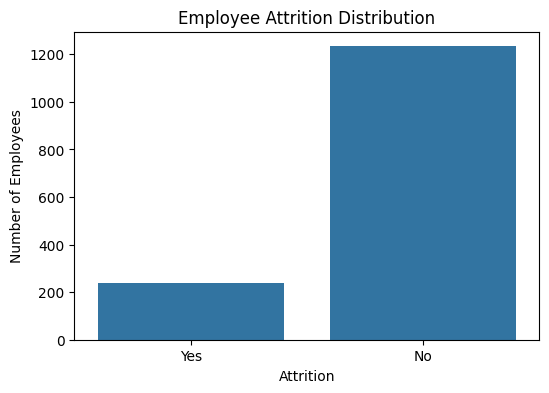

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

In [16]:
attrition_percentage = df["Attrition"].value_counts(normalize=True) * 100

print("Attrition Percentage:")
print(attrition_percentage)

Attrition Percentage:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


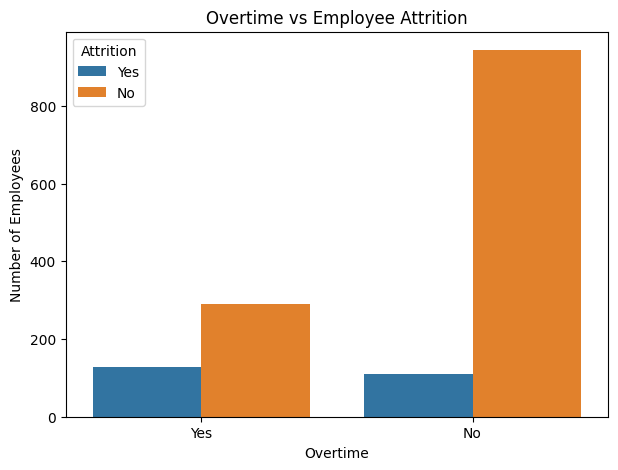

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="OverTime", hue="Attrition")

plt.title("Overtime vs Employee Attrition")
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")

plt.show()

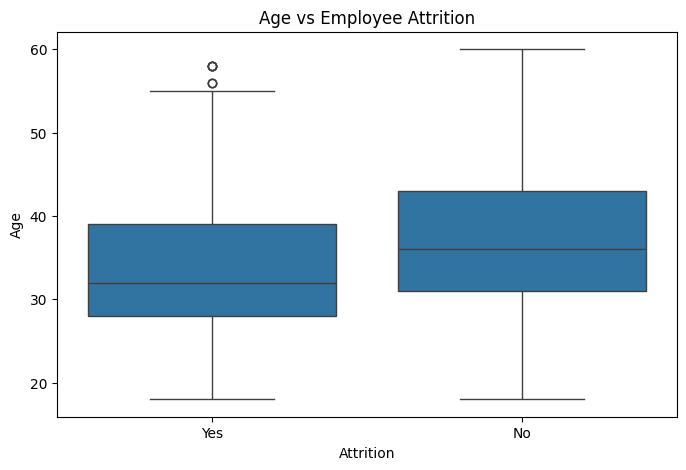

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Attrition", y="Age")

plt.title("Age vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")

plt.show()

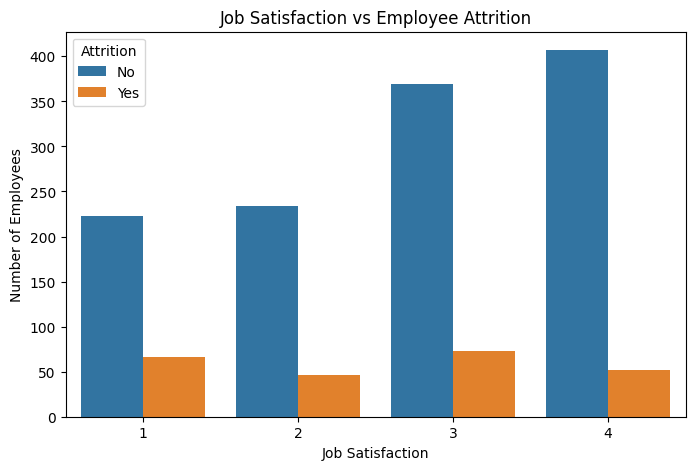

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="JobSatisfaction", hue="Attrition")

plt.title("Job Satisfaction vs Employee Attrition")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Employees")

plt.show()

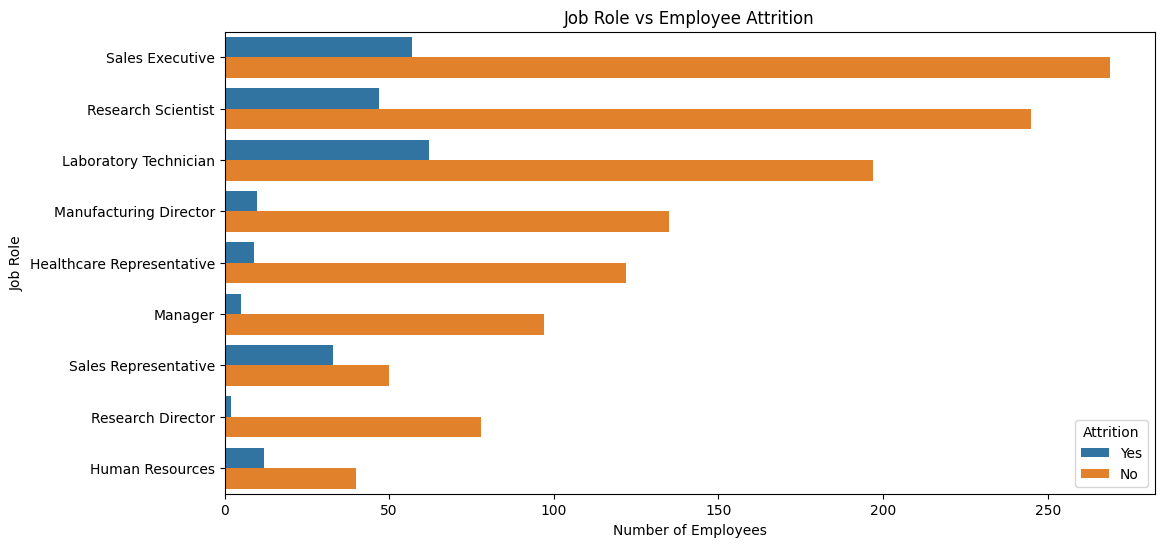

In [20]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df, y="JobRole", hue="Attrition")

plt.title("Job Role vs Employee Attrition")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")

plt.show()

In [21]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check missing values
print("Total missing values:", df.isnull().sum().sum())

# Remove unnecessary columns
df = df.drop(columns=[
    "EmployeeCount",
    "Over18",
    "StandardHours",
    "EmployeeNumber"
])

print("\nUnnecessary columns removed successfully!")
print("New dataset shape:", df.shape)

Duplicate rows: 0
Total missing values: 0

Unnecessary columns removed successfully!
New dataset shape: (1470, 31)


In [22]:
df["Attrition"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

print(df["Attrition"].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [23]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(list(categorical_columns))

Categorical Columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [24]:
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("Categorical data encoded successfully!")
print("Final dataset shape:", df.shape)

Categorical data encoded successfully!
Final dataset shape: (1470, 45)


In [25]:
print("Dataset after preprocessing:")
display(df.head())

print("\nDataset information:")
df.info()

Dataset after preprocessing:


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   HourlyRate                         1470 non-null   int64
 7   JobInvolvement                     1470 non-null   int64
 8   JobLevel                           1470 non-null   int64
 9   JobSatisfaction                    1470 non-null   int64
 10  MonthlyIncome                      1470 non-null   int64
 11  MonthlyRate                        1470 non-null   int64
 12

In [26]:
# Separate features and target

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (1470, 44)
Target (y) shape: (1470,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1176, 44)
Testing data: (294, 44)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [30]:
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!
First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", round(accuracy * 100, 2), "%")

Model Accuracy: 0.8605442176870748
Model Accuracy (%): 86.05 %


In [32]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Stayed", "Left"]
))

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92       247
        Left       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



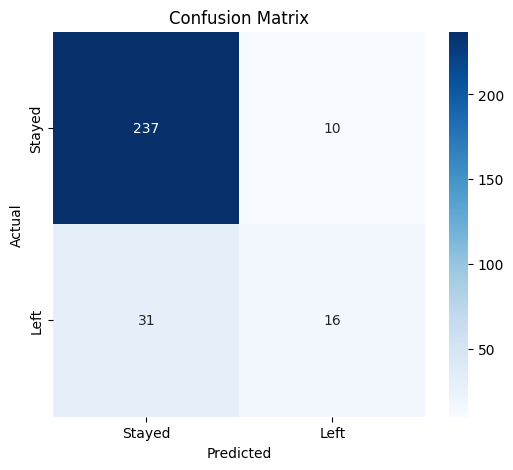

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [34]:
from sklearn.metrics import roc_auc_score

y_probability = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.8079


In [35]:
# Feature importance using Logistic Regression coefficients

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_[0]
})

# Absolute importance for ranking
feature_importance["Absolute_Importance"] = (
    feature_importance["Importance"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Absolute_Importance",
    ascending=False
)

print("Top 15 Important Features:")
display(feature_importance.head(15))

Top 15 Important Features:


,Feature,Importance,Absolute_Importance
43,OverTime_Yes,0.864567,0.864567
23,BusinessTravel_Travel_Frequently,0.751247,0.751247
34,JobRole_Laboratory Technician,0.714756,0.714756
16,TotalWorkingYears,-0.555603,0.555603
21,YearsSinceLastPromotion,0.528704,0.528704
11,NumCompaniesWorked,0.487609,0.487609
4,EnvironmentSatisfaction,-0.481659,0.481659
40,JobRole_Sales Representative,0.481459,0.481459
24,BusinessTravel_Travel_Rarely,0.450070,0.450070
8,JobSatisfaction,-0.419417,0.419417


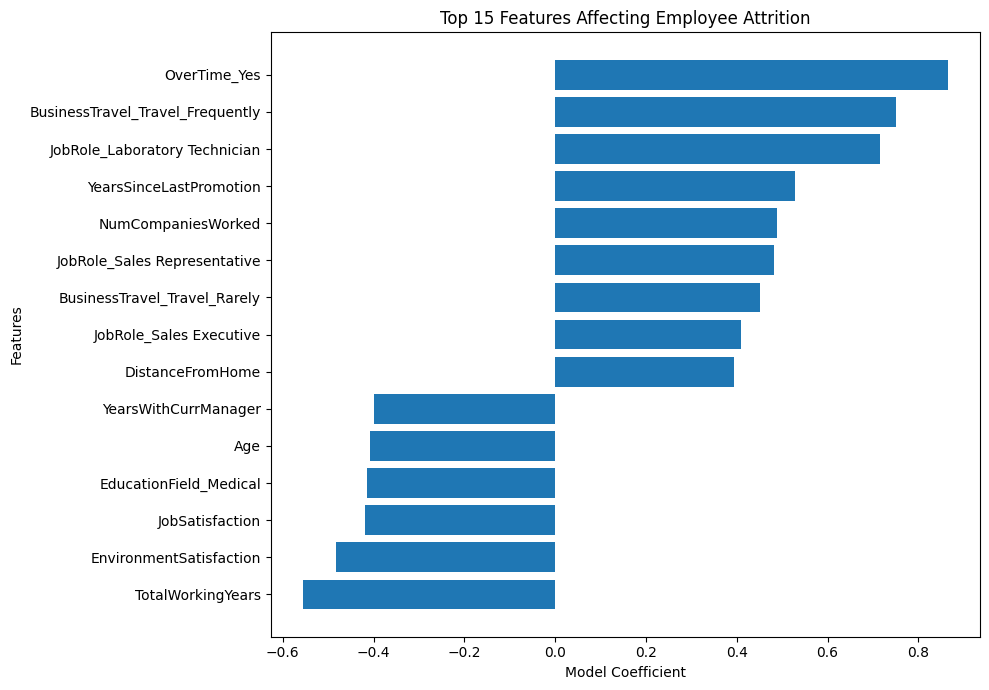

In [36]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features Affecting Employee Attrition")
plt.xlabel("Model Coefficient")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [37]:
from sklearn.linear_model import LogisticRegression

# Improved Logistic Regression model
balanced_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

# Train the improved model
balanced_model.fit(X_train_scaled, y_train)

print("Improved model trained successfully!")

Improved model trained successfully!


In [38]:
# Make predictions using the improved model

y_pred_balanced = balanced_model.predict(X_test_scaled)

print("Improved model predictions generated!")
print(y_pred_balanced[:20])

Improved model predictions generated!
[0 0 0 0 1 1 0 0 0 0 0 1 1 1 1 1 0 0 1 0]


In [39]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Accuracy
balanced_accuracy = accuracy_score(y_test, y_pred_balanced)

print("Improved Model Accuracy:", round(balanced_accuracy * 100, 2), "%")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_balanced,
    target_names=["Stayed", "Left"]
))

# ROC-AUC
y_probability_balanced = balanced_model.predict_proba(X_test_scaled)[:, 1]

balanced_roc_auc = roc_auc_score(
    y_test,
    y_probability_balanced
)

print("Improved Model ROC-AUC:", round(balanced_roc_auc, 4))

Improved Model Accuracy: 75.17 %

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.91      0.78      0.84       247
        Left       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294

Improved Model ROC-AUC: 0.7983


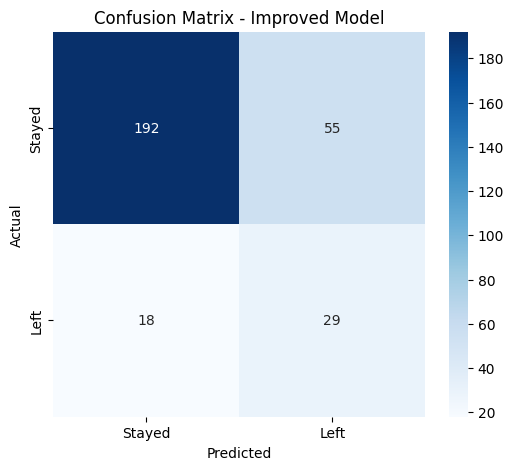

In [40]:
from sklearn.metrics import confusion_matrix

cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Confusion Matrix - Improved Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Old model metrics
old_accuracy = accuracy_score(y_test, y_pred)
old_precision = precision_score(y_test, y_pred)
old_recall = recall_score(y_test, y_pred)
old_f1 = f1_score(y_test, y_pred)

y_prob_old = model.predict_proba(X_test_scaled)[:, 1]
old_roc_auc = roc_auc_score(y_test, y_prob_old)

# Improved model metrics
new_accuracy = accuracy_score(y_test, y_pred_balanced)
new_precision = precision_score(y_test, y_pred_balanced)
new_recall = recall_score(y_test, y_pred_balanced)
new_f1 = f1_score(y_test, y_pred_balanced)

new_roc_auc = roc_auc_score(
    y_test,
    y_probability_balanced
)

# Comparison table
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Left)",
        "Recall (Left)",
        "F1 Score (Left)",
        "ROC-AUC"
    ],
    "Original Model": [
        old_accuracy,
        old_precision,
        old_recall,
        old_f1,
        old_roc_auc
    ],
    "Improved Model": [
        new_accuracy,
        new_precision,
        new_recall,
        new_f1,
        new_roc_auc
    ]
})

comparison["Original Model"] = comparison["Original Model"].round(4)
comparison["Improved Model"] = comparison["Improved Model"].round(4)

display(comparison)

,Metric,Original Model,Improved Model
0,Accuracy,0.8605,0.7517
1,Precision (Left),0.6154,0.3452
2,Recall (Left),0.3404,0.6170
3,F1 Score (Left),0.4384,0.4427
4,ROC-AUC,0.8079,0.7983


In [42]:
balanced_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": balanced_model.coef_[0]
})

balanced_feature_importance["Absolute_Importance"] = (
    balanced_feature_importance["Importance"].abs()
)

balanced_feature_importance = balanced_feature_importance.sort_values(
    by="Absolute_Importance",
    ascending=False
)

print("Top 15 Features in Improved Model:")
display(balanced_feature_importance.head(15))

Top 15 Features in Improved Model:


,Feature,Importance,Absolute_Importance
34,JobRole_Laboratory Technician,0.810172,0.810172
43,OverTime_Yes,0.771095,0.771095
23,BusinessTravel_Travel_Frequently,0.722538,0.722538
16,TotalWorkingYears,-0.660270,0.660270
7,JobLevel,0.650173,0.650173
40,JobRole_Sales Representative,0.531090,0.531090
24,BusinessTravel_Travel_Rarely,0.512780,0.512780
27,EducationField_Life Sciences,-0.512319,0.512319
21,YearsSinceLastPromotion,0.499063,0.499063
26,Department_Sales,0.470587,0.470587


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# -------------------------------
# ORIGINAL MODEL
# -------------------------------

old_accuracy = accuracy_score(y_test, y_pred)
old_precision = precision_score(y_test, y_pred)
old_recall = recall_score(y_test, y_pred)
old_f1 = f1_score(y_test, y_pred)

y_prob_old = model.predict_proba(X_test_scaled)[:, 1]
old_roc_auc = roc_auc_score(y_test, y_prob_old)


# -------------------------------
# IMPROVED MODEL
# -------------------------------

new_accuracy = accuracy_score(y_test, y_pred_balanced)
new_precision = precision_score(y_test, y_pred_balanced)
new_recall = recall_score(y_test, y_pred_balanced)
new_f1 = f1_score(y_test, y_pred_balanced)

new_roc_auc = roc_auc_score(
    y_test,
    y_probability_balanced
)


# -------------------------------
# COMPARISON TABLE
# -------------------------------

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Left)",
        "Recall (Left)",
        "F1 Score (Left)",
        "ROC-AUC"
    ],

    "Original Model": [
        old_accuracy,
        old_precision,
        old_recall,
        old_f1,
        old_roc_auc
    ],

    "Improved Model": [
        new_accuracy,
        new_precision,
        new_recall,
        new_f1,
        new_roc_auc
    ]
})

comparison["Original Model"] = comparison["Original Model"].round(4)
comparison["Improved Model"] = comparison["Improved Model"].round(4)

display(comparison)

,Metric,Original Model,Improved Model
0,Accuracy,0.8605,0.7517
1,Precision (Left),0.6154,0.3452
2,Recall (Left),0.3404,0.6170
3,F1 Score (Left),0.4384,0.4427
4,ROC-AUC,0.8079,0.7983


In [44]:
# Check the final feature columns used by the model

print("Number of features:", len(X.columns))
print("\nFeatures used by the model:")
for i, feature in enumerate(X.columns, start=1):
    print(i, feature)

Number of features: 44

Features used by the model:
1 Age
2 DailyRate
3 DistanceFromHome
4 Education
5 EnvironmentSatisfaction
6 HourlyRate
7 JobInvolvement
8 JobLevel
9 JobSatisfaction
10 MonthlyIncome
11 MonthlyRate
12 NumCompaniesWorked
13 PercentSalaryHike
14 PerformanceRating
15 RelationshipSatisfaction
16 StockOptionLevel
17 TotalWorkingYears
18 TrainingTimesLastYear
19 WorkLifeBalance
20 YearsAtCompany
21 YearsInCurrentRole
22 YearsSinceLastPromotion
23 YearsWithCurrManager
24 BusinessTravel_Travel_Frequently
25 BusinessTravel_Travel_Rarely
26 Department_Research & Development
27 Department_Sales
28 EducationField_Life Sciences
29 EducationField_Marketing
30 EducationField_Medical
31 EducationField_Other
32 EducationField_Technical Degree
33 Gender_Male
34 JobRole_Human Resources
35 JobRole_Laboratory Technician
36 JobRole_Manager
37 JobRole_Manufacturing Director
38 JobRole_Research Director
39 JobRole_Research Scientist
40 JobRole_Sales Executive
41 JobRole_Sales Representativ

In [46]:
# ==========================================
# EMPLOYEE ATTRITION PREDICTION SYSTEM
# ==========================================

def predict_attrition(employee_data):

    # Convert input dictionary into DataFrame
    new_employee = pd.DataFrame([employee_data])

    # Convert categorical columns using the same encoding method
    new_employee = pd.get_dummies(
        new_employee,
        columns=categorical_columns,
        drop_first=True
    )

    # Make sure the new data has exactly the same 44 features
    new_employee = new_employee.reindex(
        columns=X.columns,
        fill_value=0
    )

    # Scale the data using the scaler already fitted on training data
    new_employee_scaled = scaler.transform(new_employee)

    # Prediction
    prediction = balanced_model.predict(new_employee_scaled)[0]

    # Probability of leaving
    probability = balanced_model.predict_proba(
        new_employee_scaled
    )[0][1]

    # Display result
    print("===================================")
    print("   EMPLOYEE ATTRITION PREDICTION")
    print("===================================")

    if prediction == 1:
        print("Prediction : EMPLOYEE MAY LEAVE")
    else:
        print("Prediction : EMPLOYEE LIKELY TO STAY")

    print(f"Attrition Probability: {probability * 100:.2f}%")
    print("===================================")

    return prediction, probability

In [47]:
sample_employee = {
    "Age": 30,
    "DailyRate": 800,
    "DistanceFromHome": 10,
    "Education": 3,
    "EnvironmentSatisfaction": 3,
    "HourlyRate": 70,
    "JobInvolvement": 3,
    "JobLevel": 2,
    "JobSatisfaction": 3,
    "MonthlyIncome": 5000,
    "MonthlyRate": 15000,
    "NumCompaniesWorked": 2,
    "PercentSalaryHike": 15,
    "PerformanceRating": 3,
    "RelationshipSatisfaction": 3,
    "StockOptionLevel": 1,
    "TotalWorkingYears": 8,
    "TrainingTimesLastYear": 3,
    "WorkLifeBalance": 3,
    "YearsAtCompany": 5,
    "YearsInCurrentRole": 3,
    "YearsSinceLastPromotion": 1,
    "YearsWithCurrManager": 3,

    "BusinessTravel": "Travel_Rarely",
    "Department": "Sales",
    "EducationField": "Life Sciences",
    "Gender": "Male",
    "JobRole": "Sales Executive",
    "MaritalStatus": "Single",
    "OverTime": "Yes"
}

prediction, probability = predict_attrition(sample_employee)

   EMPLOYEE ATTRITION PREDICTION
Prediction : EMPLOYEE LIKELY TO STAY
Attrition Probability: 1.40%


In [48]:
import ipywidgets as widgets
from IPython.display import display, HTML

# ==========================================
# EMPLOYEE ATTRITION PREDICTION GUI
# ==========================================

# ---------- NUMERIC INPUTS ----------

age = widgets.IntText(value=30, description="Age:")
daily_rate = widgets.IntText(value=800, description="Daily Rate:")
distance = widgets.IntText(value=10, description="Distance:")
education = widgets.IntText(value=3, description="Education:")
environment = widgets.IntText(value=3, description="Env. Satisfaction:")
hourly_rate = widgets.IntText(value=70, description="Hourly Rate:")
job_involvement = widgets.IntText(value=3, description="Job Involvement:")
job_level = widgets.IntText(value=2, description="Job Level:")
job_satisfaction = widgets.IntText(value=3, description="Job Satisfaction:")
monthly_income = widgets.IntText(value=5000, description="Monthly Income:")
monthly_rate = widgets.IntText(value=15000, description="Monthly Rate:")
num_companies = widgets.IntText(value=2, description="Companies Worked:")
salary_hike = widgets.IntText(value=15, description="Salary Hike %:")
performance = widgets.IntText(value=3, description="Performance:")
relationship = widgets.IntText(value=3, description="Relationship Sat.:")
stock_option = widgets.IntText(value=1, description="Stock Option:")
total_years = widgets.IntText(value=8, description="Total Working Years:")
training = widgets.IntText(value=3, description="Training / Year:")
worklife = widgets.IntText(value=3, description="Work-Life Balance:")
years_company = widgets.IntText(value=5, description="Years at Company:")
years_role = widgets.IntText(value=3, description="Years in Role:")
years_promotion = widgets.IntText(value=1, description="Years Since Promo:")
years_manager = widgets.IntText(value=3, description="Years with Manager:")


# ---------- CATEGORICAL INPUTS ----------

business_travel = widgets.Dropdown(
    options=["Travel_Rarely", "Travel_Frequently", "Non-Travel"],
    value="Travel_Rarely",
    description="Travel:"
)

department = widgets.Dropdown(
    options=["Sales", "Research & Development", "Human Resources"],
    value="Sales",
    description="Department:"
)

education_field = widgets.Dropdown(
    options=[
        "Life Sciences",
        "Medical",
        "Marketing",
        "Technical Degree",
        "Human Resources",
        "Other"
    ],
    value="Life Sciences",
    description="Education Field:"
)

gender = widgets.Dropdown(
    options=["Male", "Female"],
    value="Male",
    description="Gender:"
)

job_role = widgets.Dropdown(
    options=[
        "Sales Executive",
        "Research Scientist",
        "Laboratory Technician",
        "Manufacturing Director",
        "Healthcare Representative",
        "Manager",
        "Sales Representative",
        "Research Director",
        "Human Resources"
    ],
    value="Sales Executive",
    description="Job Role:"
)

marital_status = widgets.Dropdown(
    options=["Single", "Married", "Divorced"],
    value="Single",
    description="Marital Status:"
)

overtime = widgets.Dropdown(
    options=["Yes", "No"],
    value="Yes",
    description="OverTime:"
)


# ---------- BUTTON ----------

predict_button = widgets.Button(
    description="Predict Attrition",
    button_style="primary",
    icon="check"
)

output = widgets.Output()


# ---------- BUTTON FUNCTION ----------

def on_predict_clicked(b):

    with output:
        output.clear_output()

        employee_data = {
            "Age": age.value,
            "DailyRate": daily_rate.value,
            "DistanceFromHome": distance.value,
            "Education": education.value,
            "EnvironmentSatisfaction": environment.value,
            "HourlyRate": hourly_rate.value,
            "JobInvolvement": job_involvement.value,
            "JobLevel": job_level.value,
            "JobSatisfaction": job_satisfaction.value,
            "MonthlyIncome": monthly_income.value,
            "MonthlyRate": monthly_rate.value,
            "NumCompaniesWorked": num_companies.value,
            "PercentSalaryHike": salary_hike.value,
            "PerformanceRating": performance.value,
            "RelationshipSatisfaction": relationship.value,
            "StockOptionLevel": stock_option.value,
            "TotalWorkingYears": total_years.value,
            "TrainingTimesLastYear": training.value,
            "WorkLifeBalance": worklife.value,
            "YearsAtCompany": years_company.value,
            "YearsInCurrentRole": years_role.value,
            "YearsSinceLastPromotion": years_promotion.value,
            "YearsWithCurrManager": years_manager.value,

            "BusinessTravel": business_travel.value,
            "Department": department.value,
            "EducationField": education_field.value,
            "Gender": gender.value,
            "JobRole": job_role.value,
            "MaritalStatus": marital_status.value,
            "OverTime": overtime.value
        }

        prediction, probability = predict_attrition(employee_data)

        # Extra result display
        if prediction == 1:
            result = "EMPLOYEE MAY LEAVE"
        else:
            result = "EMPLOYEE LIKELY TO STAY"

        print("\n")
        print("======================================")
        print("         FINAL PREDICTION")
        print("======================================")
        print("Prediction:", result)
        print(f"Attrition Probability: {probability * 100:.2f}%")
        print("======================================")


predict_button.on_click(on_predict_clicked)


# ---------- GUI LAYOUT ----------

left_column = widgets.VBox([
    age,
    daily_rate,
    distance,
    education,
    environment,
    hourly_rate,
    job_involvement,
    job_level,
    job_satisfaction,
    monthly_income,
    monthly_rate,
    num_companies,
    salary_hike,
    performance,
    relationship
])

right_column = widgets.VBox([
    stock_option,
    total_years,
    training,
    worklife,
    years_company,
    years_role,
    years_promotion,
    years_manager,
    business_travel,
    department,
    education_field,
    gender,
    job_role,
    marital_status,
    overtime
])

title = widgets.HTML(
    value="""
    <h2 style="text-align:center;">
    Employee Attrition Prediction System
    </h2>
    <p style="text-align:center;">
    Enter employee information and click Predict Attrition
    </p>
    """
)

form = widgets.HBox(
    [left_column, right_column],
    layout=widgets.Layout(
        justify_content="center",
        gap="30px"
    )
)

display(title)
display(form)
display(predict_button)
display(output)

HTML(value='\n    <h2 style="text-align:center;">\n    Employee Attrition Prediction System\n    </h2>\n    <p…

Button(button_style='primary', description='Predict Attrition', icon='check', style=ButtonStyle())

Output()

In [49]:
import ipywidgets as widgets
from IPython.display import display, HTML

# ==========================================
# CLEAN EMPLOYEE ATTRITION PREDICTION GUI
# ==========================================

# ---------- INPUT FIELDS ----------

age = widgets.IntText(value=35, description="Age:")
daily_rate = widgets.IntText(value=800, description="Daily Rate:")
distance = widgets.IntText(value=30, description="Distance:")
education = widgets.IntText(value=3, description="Education:")
environment = widgets.IntText(value=3, description="Env. Satisfaction:")
hourly_rate = widgets.IntText(value=70, description="Hourly Rate:")
job_involvement = widgets.IntText(value=3, description="Job Involvement:")
job_level = widgets.IntText(value=2, description="Job Level:")
job_satisfaction = widgets.IntText(value=3, description="Job Satisfaction:")
monthly_income = widgets.IntText(value=5000, description="Monthly Income:")
monthly_rate = widgets.IntText(value=15000, description="Monthly Rate:")
num_companies = widgets.IntText(value=0, description="Companies Worked:")
salary_hike = widgets.IntText(value=15, description="Salary Hike %:")
performance = widgets.IntText(value=3, description="Performance:")
relationship = widgets.IntText(value=3, description="Relationship Sat.:")

stock_option = widgets.IntText(value=1, description="Stock Option:")
total_years = widgets.IntText(value=8, description="Total Working Years:")
training = widgets.IntText(value=3, description="Training / Year:")
worklife = widgets.IntText(value=3, description="Work-Life Balance:")
years_company = widgets.IntText(value=5, description="Years at Company:")
years_role = widgets.IntText(value=3, description="Years in Role:")
years_promotion = widgets.IntText(value=1, description="Years Since Promo:")
years_manager = widgets.IntText(value=3, description="Years with Manager:")

# ---------- DROPDOWNS ----------

business_travel = widgets.Dropdown(
    options=["Travel_Rarely", "Travel_Frequently", "Non-Travel"],
    value="Travel_Rarely",
    description="Travel:"
)

department = widgets.Dropdown(
    options=["Sales", "Research & Development", "Human Resources"],
    value="Sales",
    description="Department:"
)

education_field = widgets.Dropdown(
    options=[
        "Life Sciences",
        "Medical",
        "Marketing",
        "Technical Degree",
        "Human Resources",
        "Other"
    ],
    value="Life Sciences",
    description="Education Field:"
)

gender = widgets.Dropdown(
    options=["Male", "Female"],
    value="Male",
    description="Gender:"
)

job_role = widgets.Dropdown(
    options=[
        "Sales Executive",
        "Research Scientist",
        "Laboratory Technician",
        "Manufacturing Director",
        "Healthcare Representative",
        "Manager",
        "Sales Representative",
        "Research Director",
        "Human Resources"
    ],
    value="Sales Executive",
    description="Job Role:"
)

marital_status = widgets.Dropdown(
    options=["Single", "Married", "Divorced"],
    value="Single",
    description="Marital Status:"
)

overtime = widgets.Dropdown(
    options=["Yes", "No"],
    value="Yes",
    description="OverTime:"
)

# ---------- BUTTON ----------

predict_button = widgets.Button(
    description="Predict Attrition",
    button_style="primary"
)

output = widgets.Output()

# ---------- PREDICTION FUNCTION ----------

def predict_button_clicked(b):

    with output:
        output.clear_output()

        employee_data = {
            "Age": age.value,
            "DailyRate": daily_rate.value,
            "DistanceFromHome": distance.value,
            "Education": education.value,
            "EnvironmentSatisfaction": environment.value,
            "HourlyRate": hourly_rate.value,
            "JobInvolvement": job_involvement.value,
            "JobLevel": job_level.value,
            "JobSatisfaction": job_satisfaction.value,
            "MonthlyIncome": monthly_income.value,
            "MonthlyRate": monthly_rate.value,
            "NumCompaniesWorked": num_companies.value,
            "PercentSalaryHike": salary_hike.value,
            "PerformanceRating": performance.value,
            "RelationshipSatisfaction": relationship.value,
            "StockOptionLevel": stock_option.value,
            "TotalWorkingYears": total_years.value,
            "TrainingTimesLastYear": training.value,
            "WorkLifeBalance": worklife.value,
            "YearsAtCompany": years_company.value,
            "YearsInCurrentRole": years_role.value,
            "YearsSinceLastPromotion": years_promotion.value,
            "YearsWithCurrManager": years_manager.value,

            "BusinessTravel": business_travel.value,
            "Department": department.value,
            "EducationField": education_field.value,
            "Gender": gender.value,
            "JobRole": job_role.value,
            "MaritalStatus": marital_status.value,
            "OverTime": overtime.value
        }

        # Prepare employee data
        new_employee = pd.DataFrame([employee_data])

        new_employee = pd.get_dummies(
            new_employee,
            columns=categorical_columns,
            drop_first=True
        )

        new_employee = new_employee.reindex(
            columns=X.columns,
            fill_value=0
        )

        new_employee_scaled = scaler.transform(new_employee)

        prediction = balanced_model.predict(new_employee_scaled)[0]

        probability = balanced_model.predict_proba(
            new_employee_scaled
        )[0][1]

        # Final result
        if prediction == 1:
            result = "EMPLOYEE MAY LEAVE"
        else:
            result = "EMPLOYEE LIKELY TO STAY"

        print("======================================")
        print("      EMPLOYEE ATTRITION RESULT")
        print("======================================")
        print(f"Prediction           : {result}")
        print(f"Attrition Probability: {probability * 100:.2f}%")
        print("======================================")


predict_button.on_click(predict_button_clicked)

# ---------- DISPLAY ----------

title = widgets.HTML(
    value="""
    <h2 style="text-align:center;">
        Employee Attrition Prediction System
    </h2>
    <p style="text-align:center;">
        Enter employee details and click the prediction button
    </p>
    """
)

left_column = widgets.VBox([
    age,
    daily_rate,
    distance,
    education,
    environment,
    hourly_rate,
    job_involvement,
    job_level,
    job_satisfaction,
    monthly_income,
    monthly_rate,
    num_companies,
    salary_hike,
    performance,
    relationship
])

right_column = widgets.VBox([
    stock_option,
    total_years,
    training,
    worklife,
    years_company,
    years_role,
    years_promotion,
    years_manager,
    business_travel,
    department,
    education_field,
    gender,
    job_role,
    marital_status,
    overtime
])

display(title)
display(
    widgets.HBox(
        [left_column, right_column],
        layout=widgets.Layout(justify_content="center")
    )
)
display(predict_button)
display(output)

HTML(value='\n    <h2 style="text-align:center;">\n        Employee Attrition Prediction System\n    </h2>\n  …

Button(button_style='primary', description='Predict Attrition', style=ButtonStyle())

Output()

# Employee Attrition Prediction

## Project Objective

The objective of this project is to develop a machine learning system
that predicts whether an employee is likely to leave an organization
based on various employee-related factors.

The project uses historical employee data and applies data preprocessing,
exploratory data analysis, machine learning, model evaluation, and
an interactive prediction system.

The final system allows users to enter employee details and obtain
an employee attrition prediction along with the estimated probability
of attrition.


## Dataset Description

The dataset contains employee-related information such as:

- Age
- Department
- Job Role
- Monthly Income
- Job Satisfaction
- Work-Life Balance
- Overtime
- Business Travel
- Years at Company
- Total Working Years
- Distance From Home
- Job Level
- Training
- Performance Rating
- Attrition

The target variable is `Attrition`.

- `0` = Employee Stayed
- `1` = Employee Left

The dataset contains 1,470 employee records and 35 original columns.
After preprocessing and encoding categorical variables, 44 features
were used for machine learning.


## Model Performance

Two Logistic Regression models were developed and compared.

### Original Model

- Accuracy: 86.05%
- Precision (Left): 61.54%
- Recall (Left): 34.04%
- F1 Score (Left): 43.84%
- ROC-AUC: 0.8079

### Improved Model

The improved model used class balancing to give more attention to
the minority class (`Attrition = 1`).

- Accuracy: 75.17%
- Precision (Left): 34.52%
- Recall (Left): 61.70%
- F1 Score (Left): 44.27%
- ROC-AUC: 0.7983

The improved model substantially increased recall for employees
who actually left the organization, from 34.04% to 61.70%.

## Conclusion

This project demonstrates how machine learning can be used to
predict employee attrition.

The analysis showed that factors such as overtime, business travel,
job role, job level, years since last promotion, distance from home,
and other employee characteristics are important in the model's
predictions.

The final system provides an interactive interface where employee
details can be entered and an attrition prediction can be generated.

The model should be considered a decision-support tool rather than
a replacement for HR judgment. The predictions represent patterns
learned from historical data and should be interpreted carefully.

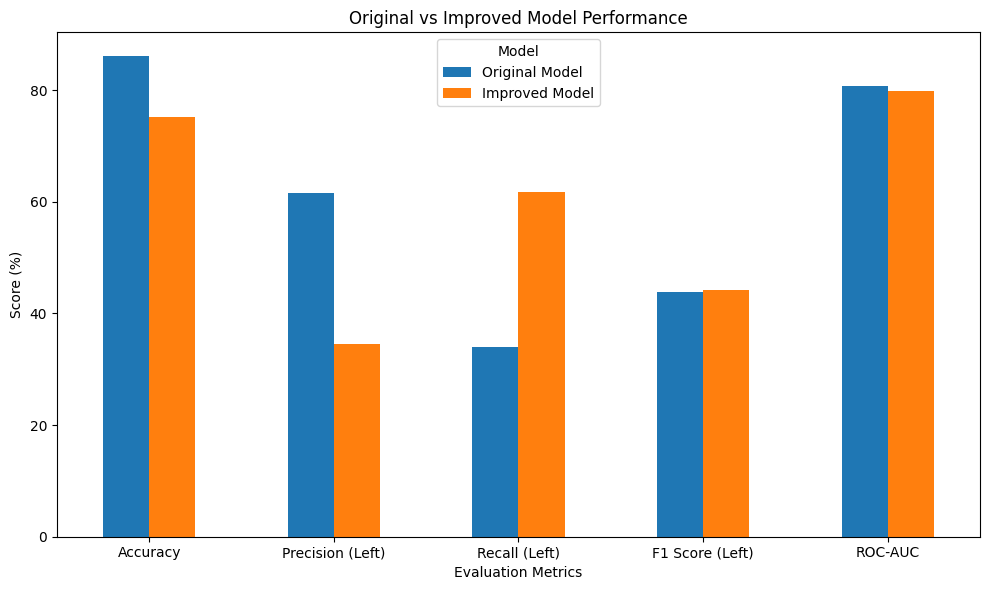

In [51]:
# ==========================================
# MODEL COMPARISON VISUALIZATION
# ==========================================

# Create a copy for plotting
plot_data = comparison.copy()

# Convert values into percentage for the chart
plot_data["Original Model"] = plot_data["Original Model"] * 100
plot_data["Improved Model"] = plot_data["Improved Model"] * 100

# Plot
ax = plot_data.plot(
    x="Metric",
    y=["Original Model", "Improved Model"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Original vs Improved Model Performance")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

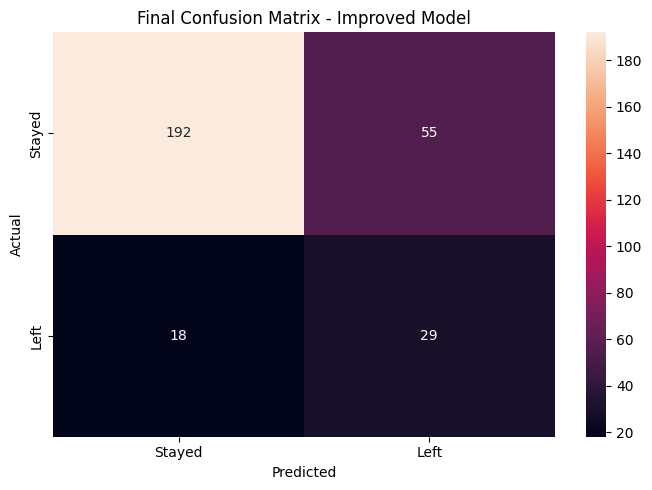

In [52]:
# ==========================================
# FINAL CONFUSION MATRIX
# ==========================================

from sklearn.metrics import confusion_matrix

final_cm = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Final Confusion Matrix - Improved Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

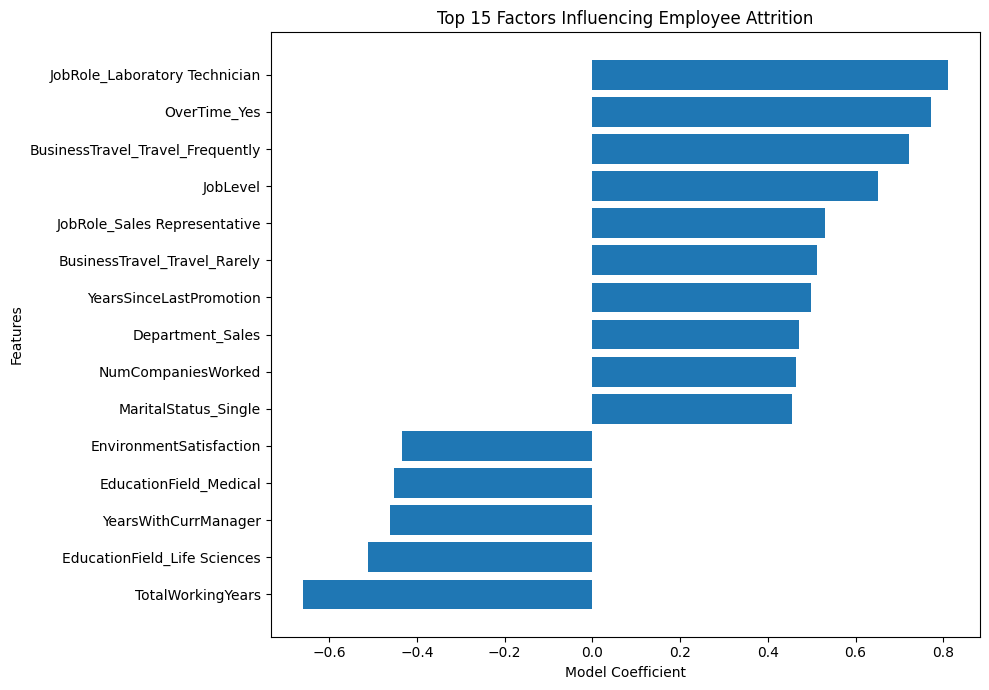

In [53]:
# ==========================================
# FINAL FEATURE IMPORTANCE
# ==========================================

top_features = balanced_feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Factors Influencing Employee Attrition")
plt.xlabel("Model Coefficient")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

# Future Scope

The Employee Attrition Prediction system can be improved further by:

1. Testing advanced machine learning algorithms such as Random Forest,
   XGBoost, and Gradient Boosting.

2. Applying advanced techniques for handling class imbalance.

3. Performing hyperparameter tuning to improve model performance.

4. Developing a web application using Streamlit or Flask.

5. Connecting the system with a real-time employee database.

6. Adding explainable AI techniques to provide better reasons behind
   individual employee predictions.

7. Continuously retraining the model with new employee data.

In [54]:
# ==========================================
# SAVE TRAINED MODEL
# ==========================================

import joblib

# Save the improved model
joblib.dump(
    balanced_model,
    "/content/employee_attrition_model.pkl"
)

# Save the scaler
joblib.dump(
    scaler,
    "/content/employee_attrition_scaler.pkl"
)

# Save the feature/column structure
joblib.dump(
    list(X.columns),
    "/content/employee_attrition_features.pkl"
)

print("======================================")
print("Model files saved successfully!")
print("======================================")
print("1. employee_attrition_model.pkl")
print("2. employee_attrition_scaler.pkl")
print("3. employee_attrition_features.pkl")

Model files saved successfully!
1. employee_attrition_model.pkl
2. employee_attrition_scaler.pkl
3. employee_attrition_features.pkl


In [55]:
import os

saved_files = [
    "/content/employee_attrition_model.pkl",
    "/content/employee_attrition_scaler.pkl",
    "/content/employee_attrition_features.pkl"
]

print("Saved files:")

for file in saved_files:
    if os.path.exists(file):
        print("✅", os.path.basename(file))
    else:
        print("❌", os.path.basename(file))

Saved files:
✅ employee_attrition_model.pkl
✅ employee_attrition_scaler.pkl
✅ employee_attrition_features.pkl


# Project Architecture

The Employee Attrition Prediction system follows the following workflow:

**Kaggle Dataset**
        ↓
**Data Loading**
        ↓
**Data Cleaning & Preprocessing**
        ↓
**Exploratory Data Analysis**
        ↓
**Categorical Encoding**
        ↓
**Train-Test Split**
        ↓
**Feature Scaling**
        ↓
**Logistic Regression**
        ↓
**Class Balancing**
        ↓
**Model Evaluation**
        ↓
**Interactive GUI**
        ↓
**Employee Attrition Prediction**

### Input

Employee information such as age, job role, income, overtime,
business travel, job satisfaction, experience, and other attributes.

### Output

The system predicts:

- Employee likely to stay
- Employee may leave

along with the estimated attrition probability.

# Final Project Summary

## Project Title

**Employee Attrition Prediction Using Machine Learning**

## Machine Learning Algorithm

**Logistic Regression**

## Improved Model Technique

**Class Weight Balancing**

## Dataset Size

**1,470 employees**

## Original Features

**35 columns**

## Final Machine Learning Features

**44 features**

## Original Model Accuracy

**86.05%**

## Improved Model Accuracy

**75.17%**

## Improved Model Recall for Attrition

**61.70%**

## Original ROC-AUC

**0.8079**

## Improved ROC-AUC

**0.7983**

## Final System

An interactive GUI allows users to enter employee information and
receive an employee attrition prediction with probability.

# Project Architecture

```text
        ┌──────────────────────────────┐
        │        Kaggle Dataset        │
        │   Employee Attrition Data    │
        └──────────────┬───────────────┘
                       ↓
        ┌──────────────────────────────┐
        │        Data Loading          │
        │           Pandas             │
        └──────────────┬───────────────┘
                       ↓
        ┌──────────────────────────────┐
        │   Data Cleaning & Checking   │
        │ Missing Values / Duplicates  │
        └──────────────┬───────────────┘
                       ↓
        ┌──────────────────────────────┐
        │   Exploratory Data Analysis  │
        │ Graphs & Statistical Analysis│
        └──────────────┬───────────────┘
                       ↓
        ┌──────────────────────────────┐
        │     Data Preprocessing       │
        │ Encoding + Feature Scaling   │
        └──────────────┬───────────────┘
                       ↓
        ┌──────────────────────────────┐
        │       Train / Test Split     │
        │            80 / 20            │
        └──────────────┬───────────────┘
                       ↓
        ┌──────────────────────────────┐
        │    Logistic Regression       │
        │      Original + Balanced     │
        └──────────────┬───────────────┘
                       ↓
        ┌──────────────────────────────┐
        │       Model Evaluation       │
        │ Accuracy / Recall / F1 / AUC │
        └──────────────┬───────────────┘
                       ↓
        ┌──────────────────────────────┐
        │      Interactive GUI          │
        │      Employee Information    │
        └──────────────┬───────────────┘
                       ↓
        ┌──────────────────────────────┐
        │    Attrition Prediction      │
        │ Stay / May Leave + Probability│
        └──────────────────────────────┘


**Shift + Enter** दबाओ।

---

# 🟢 STEP 59 — Project Results Section

अब **+ Text** पर click करो:

```markdown
# Results and Findings

The Employee Attrition Prediction project produced the following findings:

### Model Comparison

The original Logistic Regression model achieved an accuracy of 86.05%
and ROC-AUC of 0.8079.

The class-balanced Logistic Regression model achieved an accuracy of
75.17% and ROC-AUC of 0.7983.

However, the recall for employees who actually left the organization
increased from 34.04% to 61.70%.

This indicates that the balanced model is better at identifying
potential attrition cases, although it produces more false positives.

### Important Factors

The model identified several influential features, including:

- Overtime
- Business Travel
- Job Role
- Job Level
- Years Since Last Promotion
- Distance From Home
- Total Working Years
- Number of Companies Worked

These are model-derived associations and should not be interpreted
as proof that a particular factor directly causes an employee to leave.